# Progree Task 4 | The classical vision pipeline
A reproducible walkthrough of Gaussian filtering, adaptive thresholding, contour segmentation and centroid tracking. Shapes are geometric classes, not semantic labels.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0,str(ROOT))
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from src.preprocessing import VisionConfig, preprocessFrame
from src.segmentation import extractContours
from src.video_processor import FrameProcessor


## Load a real decoded frame
The supplied benchmark is generated with seed 42. Dark shapes move in separated lanes on a mildly noisy bright background.

Frame dimensions: (540, 960, 3)


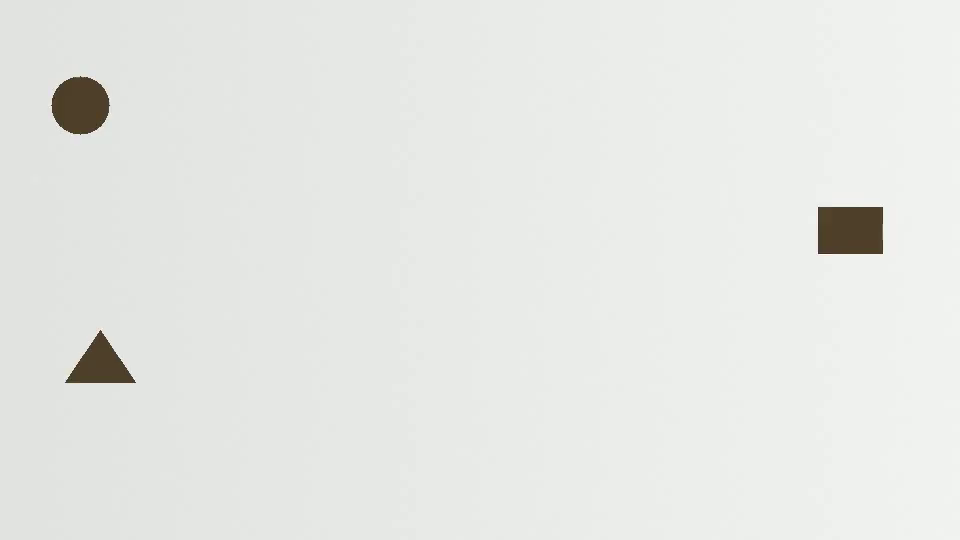

In [2]:
capture=cv2.VideoCapture(str(ROOT/"data/sample_shapes.mp4"))
assert capture.isOpened()
ok,frame=capture.read()
capture.release()
assert ok
config=VisionConfig().validate()
stages=preprocessFrame(frame,config)
print("Frame dimensions:",frame.shape)
display(Image(data=cv2.imencode(".png",frame)[1].tobytes()))

## Grayscale and Gaussian filter
Grayscale removes color dependence; the 5 x 5 Gaussian kernel suppresses high-frequency noise. This is the actual reusable preprocessing function, not a separate notebook implementation.

In [3]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,name in zip(axes,["grayscale","blurred"]):
    ax.imshow(stages[name],cmap="gray"); ax.set_title(name); ax.axis("off")
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15392\299331237.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Adaptive threshold and morphology
Gaussian-weighted local neighborhoods of 31 pixels define the threshold; C=7 is subtracted. Inverse thresholding selects dark boundaries. Closing then opening uses a 3 x 3 kernel. External contours recover enclosed shapes; the binary mask can contain hollow interiors.

In [4]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,name in zip(axes,["threshold","mask"]):
    ax.imshow(stages[name],cmap="gray"); ax.set_title(name); ax.axis("off")
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15392\769459909.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Contours, pixel bounds, geometry and centroids
External contours are filtered to 250-20,000 square pixels. Polygon approximation and circularity distinguish triangles, rectangles, circles and other contours. Moment ratios yield each centroid.

In [5]:
detections,raw=extractContours(stages["mask"],config)
print("Raw contours:",raw,"Filtered:",len(detections))
display(pd.DataFrame([{k:v for k,v in d.items() if k!="contour"} for d in detections]))

Raw contours: 3 Filtered: 3


,label,center,bbox,area,perimeter
0,Triangle,"(99, 364)","(65, 330, 70, 54)",1832.0,204.994947
1,Rectangle,"(850, 230)","(818, 207, 65, 47)",2944.0,220.000000
2,Circle,"(80, 105)","(52, 77, 57, 57)",2542.0,188.852811


## Track successive frames and render dynamic counts
Greedy nearest-centroid matching assigns each detection at most one ID and vice versa. Missing tracks expire after 10 frames; movements beyond 55 pixels create new tracks. This tracker can fail at occlusion and intersecting trajectories.

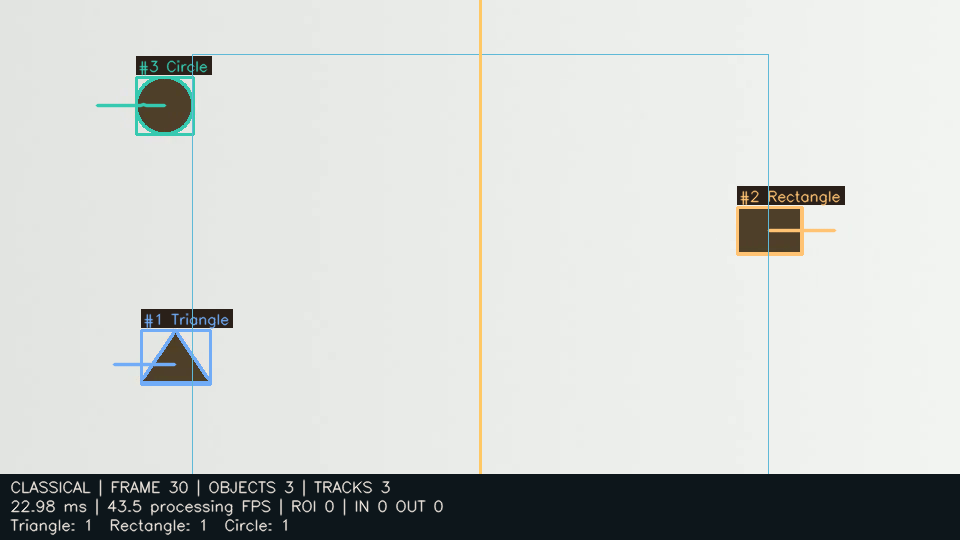

,frame_number,timestamp_seconds,objects_detected,active_tracks,processing_time_ms,fps,contour_count_raw,contour_count_filtered,inference_time_ms,class_counts,roi_objects,roi_class_counts,entered,exited,circle_count,rectangle_count,triangle_count,other_count
27,28,0.900000,3,3,22.4486,44.546208,3,3,None,"{""Triangle"": 1, ""Rectangle"": 1, ""Circle"": 1}",0,{},0,0,1,1,1,0
28,29,0.933333,3,3,22.9189,43.632111,3,3,None,"{""Triangle"": 1, ""Rectangle"": 1, ""Circle"": 1}",0,{},0,0,1,1,1,0
29,30,0.966667,3,3,22.9829,43.510610,3,3,None,"{""Triangle"": 1, ""Rectangle"": 1, ""Circle"": 1}",0,{},0,0,1,1,1,0


In [6]:
engine=FrameProcessor(config,roi=(.2,.1,.8,.9),line=.5)
capture=cv2.VideoCapture(str(ROOT/"data/sample_shapes.mp4"))
rows=[]
for number in range(1,31):
    ok,frame=capture.read()
    assert ok
    processed,row,objects=engine.process(frame,number,30)
    rows.append(row)
capture.release()
display(Image(data=cv2.imencode(".png",processed["tracked"])[1].tobytes()))
display(pd.DataFrame(rows).tail(3))

## Observations
The easy synthetic scene supports stable geometric counts. Adaptive thresholds respond to texture too: these settings should not be treated as a universal object detector. The timing covers processing and overlays, excluding decode, HUD, encoding and disk I/O. Notebook 2 evaluates the complete video.